读入并处理数据

In [2]:
import hashlib
import os
import tarfile
import zipfile
import requests

DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

def download(name, cache_dir=os.path.join('.', 'data')):
    """下载并缓存数据集，返回文件路径"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}."
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从 {url} 下载 {fname}...')
    r = requests.get(url, stream=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [3]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

# 注册数据集：名称 -> (下载地址, SHA1哈希)
DATA_HUB['kaggle_house_train'] = (
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce'
)
DATA_HUB['kaggle_house_test'] = (
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011e9f08e8dff8b00883c8e8f8e8f'
)

# 下载并读取数据
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

print(train_data.shape)
print(test_data.shape)
train_data.head()

正在从 http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv 下载 .\data\kaggle_house_pred_train.csv...
正在从 http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv 下载 .\data\kaggle_house_pred_test.csv...
(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


处理数据前要先观察数据

In [4]:
print(train_data.iloc[0:4, [0,1,2,3,-3,-2,-1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [7]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))  # 连接训练数据和测试数据方便一起处理

#### 处理数据：
1. 处理缺失值，替换为相应特征的平均值  
2. 将特征重新缩放到零均值和单位方差来标准化数据

In [13]:
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(lambda x : (x - x.mean()) / (x.std()))  # 缩放并标准化数据
all_features[numeric_features] = all_features[numeric_features].fillna(0)

处理离散值，使用独热编码来替换

In [26]:
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features = all_features.astype(float)

从pandas格式中提取Numpy格式，并将其转换为张量表示

In [ ]:
n_train = train_data.shape[0]  # 获取训练数据的行数

# 拆分训练集和验证集
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)  # 获取标签

训练

In [53]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 64), nn.ReLU(), nn.Linear(64, 1))  # in_features 个输入 → 1 个输出（预测房价）
    return net

更关心相对误差，房价的差异可能会因为房子大小而不同，房子大的房价差异很大权重也高
使用价格预测的对数来衡量差异

In [30]:
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))  # 把张量里的值限制在 [min, max] 区间内 房价不可能为负或接近零（训练标签最小值也大于 1）。训练过程中网络可能预测出负数，直接取 log 会在 nn.MSELoss 的对数误差计算中炸掉（log(负数) = NaN）。先 clamp 到 1 再取 log 就安全了。
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

训练函数

In [32]:
def train(net, train_features, train_labels, test_features, test_labels, num_epoch, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for epoch in range(num_epoch):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    
    return train_ls, test_ls

K折交叉验证

In [33]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k  # 一折的大小
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j+1) * fold_size)
        X_part, y_part, = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part  # 获取验证集
        elif X_train is None:   # 如果训练集为空就直接复制
            X_train, y_train = X_part, y_part  # 获取训练集
        else:  # 如果训练集不为空就凭借成为新数据集
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

返回训练和验证误差的平均值

In [34]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs+1],
                     legend=['train', 'valid'], yscale='log')
        print(f'fold {i+1}, train log rmse {float(train_ls[-1]):f}',
              f'valid log rmse {float(valid_ls[-1]):f}')
        
    return train_l_sum / k, valid_l_sum / k  # 返回均值损失

模型选择

fold 1, train log rmse 0.137417 valid log rmse 0.145612
fold 2, train log rmse 0.133920 valid log rmse 0.149257
fold 3, train log rmse 0.134974 valid log rmse 0.143117
fold 4, train log rmse 0.139333 valid log rmse 0.140225
fold 5, train log rmse 0.133742 valid log rmse 0.171022
5-折验证：平均训练log rmse：0.135877,平均验证log rmse：0.149847


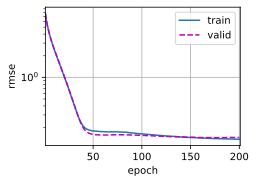

In [55]:
k, num_epochs, lr, weight_decay, batch_size = 5, 200, 0.01, 1e-3, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)

print(f'{k}-折验证：平均训练log rmse：{float(train_l):f},'
      f'平均验证log rmse：{float(valid_l):f}')